In [1]:
from flowstab.flow_stability import FlowStability
from flowstab.network_clustering import Clustering,avg_norm_var_information, run_multi_louvain
import pandas as pd
import numpy as np
from tqdm import tqdm
import gc

from collections import defaultdict
import pygenstability as pgs
import multiprocessing

# Implementation of Flow Stability run with scale selection

In [2]:
def _convert_sets_to_community_id(partitions_set, N):
    """Convert a list of partitions in set format to a list of community id arrays."""
    partitions_id = []
    for partition in partitions_set:
        partition_id = np.zeros(N, dtype=int)
        for cluster_id, cluster in enumerate(partition):
            for node in cluster:
                partition_id[node] = cluster_id
        partitions_id.append(partition_id)
    return partitions_id

In [3]:
def run(
    events_table,
    min_scale=-2,
    max_scale=0.5,
    n_scale=20,
    log_scale=True,
    n_tries=100,
    result_file="results.pkl",
    n_workers=4,
    n_NVI=20,
    with_optimal_scales=True,
    optimal_scales_kwargs=None,
    with_all_tries=False,
):

    nodes = np.unique(
        pd.concat([events_table["source_nodes"], events_table["target_nodes"]])
    )
    n_nodes = len(nodes)

    # initialise results dictionary
    all_results = defaultdict(list)

    if log_scale:
        scales = np.logspace(min_scale, max_scale, n_scale)
    else:
        scales = np.linspace(min_scale, max_scale, n_scale)

    taus = 1 / scales

    run_params = {
        "min_scale": min_scale,
        "max_scale": max_scale,
        "n_scale": n_scale,
        "log_scale": log_scale,
        "n_tries": n_tries,
        "n_workers": n_workers,
        "n_NVI": n_NVI,
    }

    all_results["run_params"] = run_params
    all_results["scales"] = scales.tolist()

    # initilise FS object and compute inter-transition matrices for all taus
    fs = FlowStability()
    fs.set_temporal_network(events_table=events_table, relabel_nodes=True)
    fs.compute_laplacian_matrices()
    fs.set_time_scale(taus)
    fs.compute_inter_transition_matrices()
    fs.time_direction = 0
    fs.set_flow_clustering()
    fs._temporal_network.inter_T = None

    # free up memory
    gc.collect()

    # create forward and backward results dictionaries
    f_results = all_results.copy()
    b_results = all_results.copy()

    with multiprocessing.Pool(n_workers) as pool:

        ###############
        # forward run #
        ###############

        # compute forward partitions for all taus
        for tau in tqdm(taus, desc="Computing forward partitions"):

            clus_obj_for = fs.flow_clustering_forward[tau]

            # Run Louvain
            _, cluster_lists, stabilities, _ = run_multi_louvain(
                Clustering(p1=clus_obj_for.p1, p2=None, S=clus_obj_for.I_list[0]),
                num_repeat=n_tries,
            )

            # Convert partitions to partition ID format
            partitions_id = _convert_sets_to_community_id(cluster_lists, n_nodes)

            # Find the partition with the highest stability
            best_id = np.argmax(stabilities)
            all_results["community_id_f"].append(partitions_id[best_id])
            all_results["stability_f"].append(stabilities[best_id])
            all_results["number_of_communities_f"].append(
                len(np.unique(partitions_id[best_id]))
            )

            if with_all_tries:
                all_results["all_tries_f"].append(partitions_id)

            f_results["community_id"].append(partitions_id[best_id])

            # Compute within-scales NVI
            pgs.pygenstability._compute_NVI(
                partitions_id, f_results, pool, n_partitions=n_NVI
            )
            all_results["NVI_f"].append(f_results["NVI"][-1])

            # free up memory
            fs.flow_clustering_forward[tau] = None
            gc.collect()

            # save results
            pgs.save_results(all_results, filename=result_file)

        # Compute across-scales NVI
        pgs.pygenstability._compute_ttprime(f_results, pool)
        all_results["ttprime_f"] = f_results["ttprime"]

        # save results
        pgs.save_results(all_results, filename=result_file)

        ################
        # backward run #
        ################

        # compute backward partitions for all taus
        for tau in tqdm(taus, desc="Computing backward partitions"):

            clus_obj_for = fs.flow_clustering_backward[tau]

            # Run Louvain
            _, cluster_lists, stabilities, _ = run_multi_louvain(
                Clustering(p1=clus_obj_for.p1, p2=None, S=clus_obj_for.I_list[0]),
                num_repeat=n_tries,
            )

            # Convert partitions to partition ID format
            partitions_id = _convert_sets_to_community_id(cluster_lists, n_nodes)

            # Find the partition with the highest stability
            best_id = np.argmax(stabilities)
            all_results["community_id_b"].append(partitions_id[best_id])
            all_results["stability_b"].append(stabilities[best_id])
            all_results["number_of_communities_b"].append(
                len(np.unique(partitions_id[best_id]))
            )

            if with_all_tries:
                all_results["all_tries_b"].append(partitions_id)

            b_results["community_id"].append(partitions_id[best_id])

            # Compute within-scales NVI
            pgs.pygenstability._compute_NVI(
                partitions_id, b_results, pool, n_partitions=n_NVI
            )
            all_results["NVI_b"].append(b_results["NVI"][-1])

            # free up memory
            fs.flow_clustering_backward[tau] = None
            gc.collect()

            # save results
            pgs.save_results(all_results, filename=result_file)

        # Compute across-scales NVI
        pgs.pygenstability._compute_ttprime(b_results, pool)
        all_results["ttprime_b"] = b_results["ttprime"]

        # save results
        pgs.save_results(all_results, filename=result_file)

    ###################
    # scale selection #
    ###################

    del fs
    gc.collect()

    if with_optimal_scales:

        # identify optimal scales
        if optimal_scales_kwargs is None:
            optimal_scales_kwargs = {
                "kernel_size": max(2, int(0.1 * n_scale)),
                "window_size": max(2, int(0.1 * n_scale)),
                "basin_radius": max(1, int(0.01 * n_scale)),
            }

        # identifiy optimal scales in forward partitions
        f_results = pgs.identify_optimal_scales(f_results, **optimal_scales_kwargs)
        all_results["block_nvi_f"] = f_results["block_nvi"]
        all_results["selected_partitions_f"] = f_results["selected_partitions"]

        # identifiy optimal scales in backward partitions
        b_results = pgs.identify_optimal_scales(b_results, **optimal_scales_kwargs)
        all_results["block_nvi_b"] = b_results["block_nvi"]
        all_results["selected_partitions_b"] = b_results["selected_partitions"]

        # save results
        pgs.save_results(all_results, result_file)

    return all_results

# Application to primary school data

In [4]:
# load primary school data
df = pd.read_csv("primary_school_data/primary_school_day2.csv")

# define parameters for FS run, using same parameter names as in PyGenStability
min_scale = -7
max_scale = 2
n_scale = 20
log_scale = True
n_tries = 100 
result_file="results.pkl"
n_workers = 4
n_NVI = 20
with_optimal_scales=True
with_all_tries=False
# optimal_scales_kwargs = {
#     "kernel_size": 10,
#     "window_size": 10,
#     "basin_radius": 2
# }

In [5]:
all_results = run(
    events_table=df,
    min_scale=min_scale,
    max_scale=max_scale,
    n_scale=n_scale,
    log_scale=log_scale,
    n_tries=n_tries,
    result_file="results_forward.pkl",
    n_workers=n_workers,
    n_NVI=n_NVI,
    with_optimal_scales=with_optimal_scales
)

2026-05-08 16:07:26,267 - INFO - flowstab/flow_stability.py:234 - PID:56187 - Set an empty temporal network.
2026-05-08 16:07:26,267 - INFO - flowstab/flow_stability.py:138 - PID:56187 - Successfully initiated a FlowStability instance!
2026-05-08 16:07:26,276 - INFO - flowstab/flow_stability.py:229 - PID:56187 - Set the temporal network: <class 'tempnet.temporal_network.ContTempNetwork'> with 238 nodes and 65150 events
2026-05-08 16:07:26,276 - INFO - tempnet/temporal_network.py:1267 - PID:56187 - Computing Laplacians
2026-05-08 16:07:26,321 - INFO - tempnet/temporal_network.py:1326 - PID:56187 - 0 over 1545
2026-05-08 16:07:26,322 - INFO - tempnet/temporal_network.py:1330 - PID:56187 - 0.00s
2026-05-08 16:07:40,549 - INFO - tempnet/temporal_network.py:1326 - PID:56187 - 1000 over 1545
2026-05-08 16:07:40,549 - INFO - tempnet/temporal_network.py:1330 - PID:56187 - 14.23s
2026-05-08 16:07:46,174 - INFO - tempnet/temporal_network.py:1377 - PID:56187 - Finished in 19.856362342834473
2026-

In [6]:
# extract forward and backward results for plotting
f_results = all_results.copy()
f_results = {key.replace("_f", ""): value for key, value in f_results.items()}
b_results = all_results.copy()
b_results = {key.replace("_b", ""): value for key, value in b_results.items()}

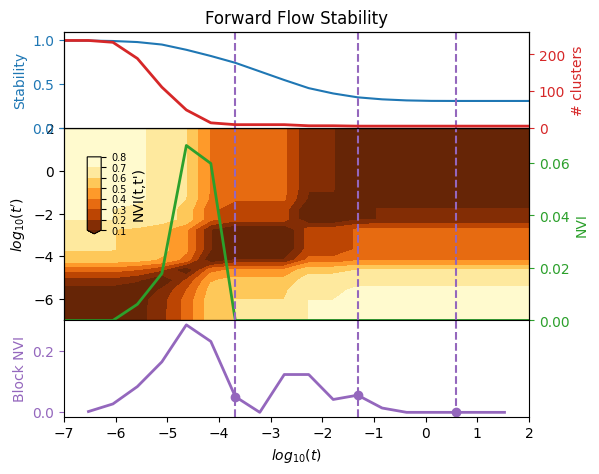

In [13]:
# plot forward results
axes = pgs.plot_scan_plt(f_results)
axes[2].set_title("Forward Flow Stability");

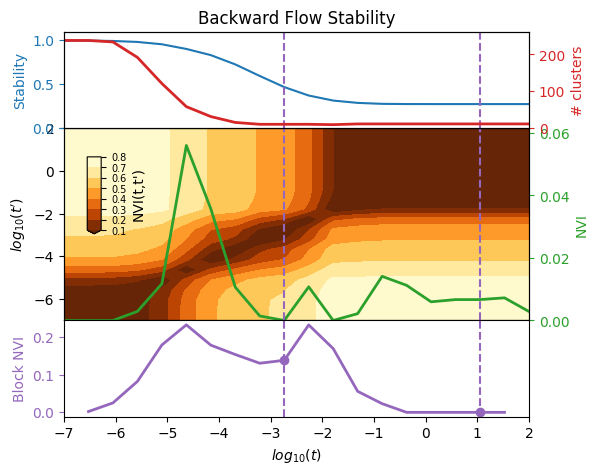

In [ ]:
# plot backward results
axes = pgs.plot_scan_plt(b_results)
axes[2].set_title("Backward Flow Stability");